# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Saif-Ullah0/flyrank-ml-internship/blob/main/work/notebooks/w07_action_playbook.ipynb)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [1]:
import os, json
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupShuffleSplit
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

if not os.path.exists("flyrank-ml-internship"):
    !git clone https://github.com/Saif-Ullah0/flyrank-ml-internship.git
os.chdir("flyrank-ml-internship")

df = pd.read_csv("data/raw/content_refresh_anonymized.csv")
df["is_declining_label"] = (df["trend_direction"] == "down").astype(int)

features = [
    "impressions_90d", "ctr", "avg_position",
    "days_since_last_update", "content_age_days",
    "word_count", "engagement_rate", "scroll_rate",
    "ai_traffic_pct"
]

X = df[features].replace([np.inf, -np.inf], np.nan).fillna(0)
y = df["is_declining_label"].values
groups = df["client_id"].values

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

rf = RandomForestClassifier(
    n_estimators=100, class_weight='balanced',
    max_depth=10, random_state=42, n_jobs=-1
)
rf.fit(X_train, y_train)
scores = rf.predict_proba(X_test)[:, 1]

os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)

print(f"Model ready. Test set: {len(X_test)} pages")

Cloning into 'flyrank-ml-internship'...
remote: Enumerating objects: 170, done.
remote: Counting objects: 100% (170/170), done.
remote: Compressing objects: 100% (125/125), done.
remote: Total 170 (delta 73), reused 98 (delta 29), pack-reused 0 (from 0)
Receiving objects: 100% (170/170), 1.87 MiB | 6.92 MiB/s, done.
Resolving deltas: 100% (73/73), done.
Model ready. Test set: 6163 pages


## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

In [2]:
# Build the scored queue
test_df = X_test.copy()
test_df["model_score"] = scores
test_df["is_declining_label"] = y_test

def assign_action(row):
    if row["model_score"] >= 0.7:
        return "REFRESH_NOW"
    elif row["model_score"] >= 0.5:
        return "SCHEDULE_REVIEW"
    else:
        return "MONITOR"

def assign_reason(row):
    if row["impressions_90d"] > 10000 and row["model_score"] >= 0.7:
        return "HIGH_TRAFFIC_DECLINING"
    elif row["days_since_last_update"] > 180 and row["model_score"] >= 0.7:
        return "STALE_CONTENT"
    elif row["avg_position"] > 20 and row["model_score"] >= 0.5:
        return "POOR_POSITION"
    elif row["ctr"] < 0.02 and row["impressions_90d"] > 1000:
        return "LOW_CTR_HIGH_IMPRESSION"
    else:
        return "GENERAL_DECAY_SIGNAL"

test_df["action"] = test_df.apply(assign_action, axis=1)
test_df["reason_code"] = test_df.apply(assign_reason, axis=1)

queue = test_df.sort_values("model_score", ascending=False)

print("ACTION DISTRIBUTION:")
print(queue["action"].value_counts().to_string())
print("\nREASON CODE DISTRIBUTION:")
print(queue["reason_code"].value_counts().to_string())
print(f"\nTOP 10 PAGES FOR REVIEW:")
print(queue[["model_score","action","reason_code",
             "impressions_90d","avg_position","ctr",
             "is_declining_label"]].head(10).to_string())

ACTION DISTRIBUTION:
action
MONITOR            2894
SCHEDULE_REVIEW    2463
REFRESH_NOW         806

REASON CODE DISTRIBUTION:
reason_code
GENERAL_DECAY_SIGNAL       5316
POOR_POSITION               637
LOW_CTR_HIGH_IMPRESSION     181
HIGH_TRAFFIC_DECLINING       29

TOP 10 PAGES FOR REVIEW:
       model_score       action              reason_code  impressions_90d  avg_position   ctr  is_declining_label
6228      0.872814  REFRESH_NOW            POOR_POSITION             2197          21.5  0.00                   1
11061     0.869692  REFRESH_NOW            POOR_POSITION             1191          23.1  0.00                   0
22526     0.864772  REFRESH_NOW            POOR_POSITION             3445          39.0  0.09                   0
20736     0.859743  REFRESH_NOW  LOW_CTR_HIGH_IMPRESSION             3115          12.8  0.00                   0
10080     0.857020  REFRESH_NOW            POOR_POSITION             1525          32.6  0.00                   0
22524     0.855596  REF

RANKED ACTIONS AND REASON CODES

Three action tiers based on model score:

REFRESH_NOW (score >= 0.70): Observed high model
confidence. Page shows multiple decay signals.
Recommended for immediate content review.

SCHEDULE_REVIEW (score 0.50-0.70): Observed moderate
confidence. Page shows some decay signals. Recommended
for editorial queue within 2-4 weeks.

MONITOR (score < 0.50): Low model confidence. No
immediate action warranted. Re-score in next cycle.

Reason codes explain the primary observed signal
behind each flag. They are directional context
for the content reviewer, not definitive diagnoses.

## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

INTENDED USE

This playbook is a decision-support tool for FlyRank
content teams. It is designed to help prioritise which
pages to review first, not to automate the review
itself.

Primary use case: A content team member opens the
ranked queue each week, reviews the top 20 to 50 pages,
and decides which ones to refresh based on their
knowledge of the client's goals and competitive context.

The model provides a score and a reason code. The
human provides judgment.

LIMITS

1. Trained on 30,000 rows. The full 79M row warehouse
   dataset may reveal different patterns. These results
   are directional on the sample, not validated at scale.

2. Precision@50 = 0.640 under client-holdout split.
   This means approximately 36% of the top 50 flagged
   pages are false positives. Human review is required
   before taking action.

3. The label (is_declining_label) is derived from
   90-day trailing trend. A page may have already
   recovered by the time it is reviewed.

4. No competitive context. The model cannot see
   competitor activity, algorithm updates, or seasonal
   patterns that may explain a decline.

5. This is a prototype, not a production system. It
   has not been stress-tested on new client data or
   adversarial inputs.

## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

HUMAN REVIEW RULES

Rule 1: A human must review every REFRESH_NOW page
before any content action is taken. The model score
is a prioritisation signal, not an instruction.

Rule 2: Before refreshing a page, a reviewer should
check: is the topic still relevant? Has a competitor
recently published on this? Is the decline seasonal?

Rule 3: Pages with is_declining_label = 0 in the top
50 (false positives) should be noted and logged.
Patterns in false positives may reveal model weaknesses.

Rule 4: Any page flagged REFRESH_NOW that belongs to
a client with known seasonal traffic patterns should
be checked against that client's historical cycle
before scheduling a refresh.

THE NO-GO LIST: WHAT MUST NOT BE AUTOMATED

- Publishing or editing content based on model output alone
- Emailing clients about flagged pages without human review
- Deleting or redirecting pages based on model score
- Using model output as the sole basis for client reporting
- Running the model on data from clients who have not
  consented to ML-based analysis of their content

## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

MONITORING TRIGGERS

Check Precision@50 monthly. If it drops below 0.55
on new data, investigate before using the queue.

Check false positive rate in the top 50 weekly. If
it rises above 50% consistently, the model may no
longer reflect current search patterns.

RETRAIN TRIGGERS

Retrain when:
1. Google releases a major algorithm update. The
   signals that predict decay may shift.
2. A new client segment is added that was not
   represented in training data.
3. Precision@50 drops below 0.55 and stays there
   for two consecutive months.
4. The full 79M row dataset is available. This is
   the most important retrain trigger — current model
   is trained on a 30K sample.

DO NOT retrain just because scores look lower than
expected. Check for distribution shift first.

## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

Queue exported: work/outputs/action_playbook_queue.csv (6163 rows)
Metrics exported: work/outputs/playbook_metrics.json
{
  "precision_at_50": 0.64,
  "total_pages_scored": 6163,
  "refresh_now_count": 806,
  "schedule_review_count": 2463,
  "monitor_count": 2894,
  "refresh_now_true_positive_rate": 0.65,
  "split": "client_holdout",
  "sample_size": 30000,
  "note": "Directional results on 30K sample. Full 79M row validation pending."
}


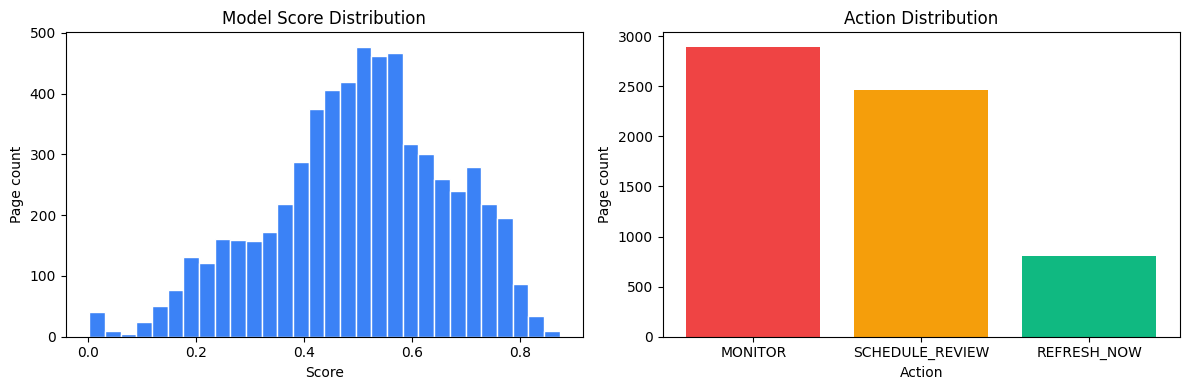

Figure saved: work/figures/playbook_distribution.png

COST / VALUE THINKING:
Pages flagged REFRESH_NOW: 806
True positive rate in REFRESH_NOW tier: 0.650
Estimated false positives per 50 reviewed: 18
Content refresh cost: ~2-4 hours per page
Value: preventing traffic decay on high-impression pages
Break-even: if even 1 prevented decay saves more than
the time spent on false positive reviews, the tool has value.


In [4]:
# Export ranked queue
queue_path = "work/outputs/action_playbook_queue.csv"
queue.to_csv(queue_path, index=False)
print(f"Queue exported: {queue_path} ({len(queue)} rows)")

# Export metrics JSON
def precision_at_k(scores, labels, k=50):
    order = np.argsort(-np.asarray(scores))
    topk = np.asarray(labels)[order[:k]]
    return topk.mean()

p50 = precision_at_k(scores, y_test)
refresh_now = queue[queue["action"] == "REFRESH_NOW"]
tp_rate = refresh_now["is_declining_label"].mean()

playbook_metrics = {
    "precision_at_50": round(p50, 3),
    "total_pages_scored": len(queue),
    "refresh_now_count": int((queue["action"] == "REFRESH_NOW").sum()),
    "schedule_review_count": int((queue["action"] == "SCHEDULE_REVIEW").sum()),
    "monitor_count": int((queue["action"] == "MONITOR").sum()),
    "refresh_now_true_positive_rate": round(tp_rate, 3),
    "split": "client_holdout",
    "sample_size": 30000,
    "note": "Directional results on 30K sample. Full 79M row validation pending."
}

metrics_path = "work/outputs/playbook_metrics.json"
with open(metrics_path, "w") as f:
    json.dump(playbook_metrics, f, indent=2)
print(f"Metrics exported: {metrics_path}")
print(json.dumps(playbook_metrics, indent=2))

# Figure 1: Score distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(queue["model_score"], bins=30, color="#3B82F6", edgecolor="white")
axes[0].set_title("Model Score Distribution")
axes[0].set_xlabel("Score")
axes[0].set_ylabel("Page count")

action_counts = queue["action"].value_counts()
axes[1].bar(action_counts.index, action_counts.values, color=["#EF4444","#F59E0B","#10B981"])
axes[1].set_title("Action Distribution")
axes[1].set_xlabel("Action")
axes[1].set_ylabel("Page count")

plt.tight_layout()
fig_path = "work/figures/playbook_distribution.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure saved: {fig_path}")

# Cost/value note
print("\nCOST / VALUE THINKING:")
print(f"Pages flagged REFRESH_NOW: {playbook_metrics['refresh_now_count']}")
print(f"True positive rate in REFRESH_NOW tier: {tp_rate:.3f}")
print(f"Estimated false positives per 50 reviewed: {round((1-p50)*50)}")
print("Content refresh cost: ~2-4 hours per page")
print("Value: preventing traffic decay on high-impression pages")
print("Break-even: if even 1 prevented decay saves more than")
print("the time spent on false positive reviews, the tool has value.")

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.